# Plotting PSDs

In this notebook we generate the Figure 1 plot for use in the paper. The PSDs and characteristic strains have been generated in estimate_psds.ipynb and characteristic_strain.ipynb respectively, so we will load them in

In [1]:


from pycbc.types import load_frequencyseries
import numpy as np

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

paper_plot_dir = '../paper/images/dataset'

import ldc.lisa.noise.noise as ldc_noise

import sys
import os

search_dir = os.path.abspath("../search")

if search_dir not in sys.path:
    sys.path.insert(0, search_dir)

import plotting_utils


/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
# This cell contains the information about input files

estimated_format = '{channel}_sangria_hm_PSD.txt'
smoothed_estimated_format = '{channel}_sangria_hm_SMOOTHED_PSD.txt'
segment_duration = 1576800

In [3]:
# Load in PSD files
A_estimate = load_frequencyseries(estimated_format.format(channel='A'))
E_estimate = load_frequencyseries(estimated_format.format(channel='E'))
T_estimate = load_frequencyseries(estimated_format.format(channel='T'))

A_smoothed = load_frequencyseries(smoothed_estimated_format.format(channel='A'))
E_smoothed = load_frequencyseries(smoothed_estimated_format.format(channel='E'))

AE_model = load_frequencyseries('model_AE_PSD.txt')
T_model = load_frequencyseries('model_T_PSD.txt')

AE_model_smoothed = load_frequencyseries('model_AE_SMOOTHED_PSD.txt')

In [4]:
# Now lets _also_ get the PSD model which doesnt include GBs - this matches the one used in the zero latency filter paper
sangria_model_freqs = A_smoothed.sample_frequencies
nm_nogb = ldc_noise.get_noise_model("sangria", sangria_model_freqs, wd=False)
ae_nogb = nm_nogb.psd(option="A")
t_nogb = nm_nogb.psd(option="T")

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:435: RuntimeWarning: divide by zero encountered in power
  return self._data ** other
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:348: RuntimeWarning: invalid value encountered in multiply
  return self._data * other


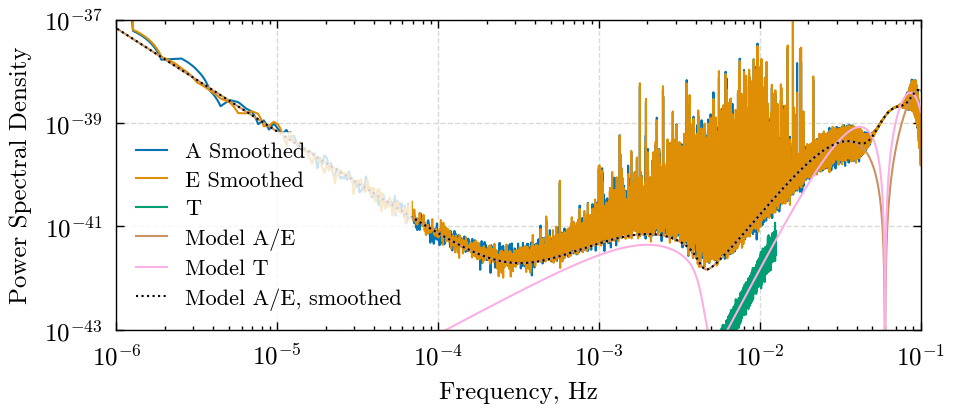

In [5]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1]
fig, ax = plt.subplots(1, figsize=(width, height))
ax.loglog(
    A_smoothed.sample_frequencies,
    A_smoothed,
    c=cycle[0],
    label='A Smoothed'
    )
ax.loglog(
    E_smoothed.sample_frequencies,
    E_smoothed,
    c=cycle[1],
    label='E Smoothed'
)
ax.loglog(
    T_estimate.sample_frequencies,
    T_estimate,
    c=cycle[2],
    label='T'
)
ax.loglog(
    AE_model.sample_frequencies,
    AE_model,
    c=cycle[5],
    label='Model A/E'
)
ax.loglog(
    T_model.sample_frequencies,
    T_model,
    c=cycle[6],
    label='Model T'
)

ax.loglog(
    AE_model_smoothed.sample_frequencies,
    AE_model_smoothed,
    c='k',
    linestyle=':',
    label='Model A/E, smoothed'
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='lower left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

fig.savefig(f'{paper_plot_dir}/figure_X_psd_model_data.png')

Now lets have a look at where the massive black hole binaries sit on this PSD plot

In [6]:
import h5py
cutoff_days = [0.5, 1, 4, 7, 14]
example_signal_number = 2

with h5py.File('characteristic_strain/collected_characteristic_strain.hdf', 'r') as ccsf:
    freqs = ccsf['frequencies'][:]
    valid = freqs > 0
    freqs = freqs[valid]
    full_char = np.sqrt(ccsf[str(example_signal_number)]['0_A'][valid] ** 2 + ccsf[str(example_signal_number)]['0_E'][valid] ** 2)
    char = {
        days: np.sqrt(ccsf[str(example_signal_number)][str(days).replace('.','p') + '_A'][valid] ** 2 + 
                      ccsf[str(example_signal_number)][str(days).replace('.','p') + '_E'][valid] ** 2)
        for days in cutoff_days
    }

# days before merger to use as cutoffs
cutoff_days = [0.5, 1, 4, 7, 14]

time_before_colors = plotting_utils.get_colors(cutoff_days)
time_before_colors[0] = 'k'

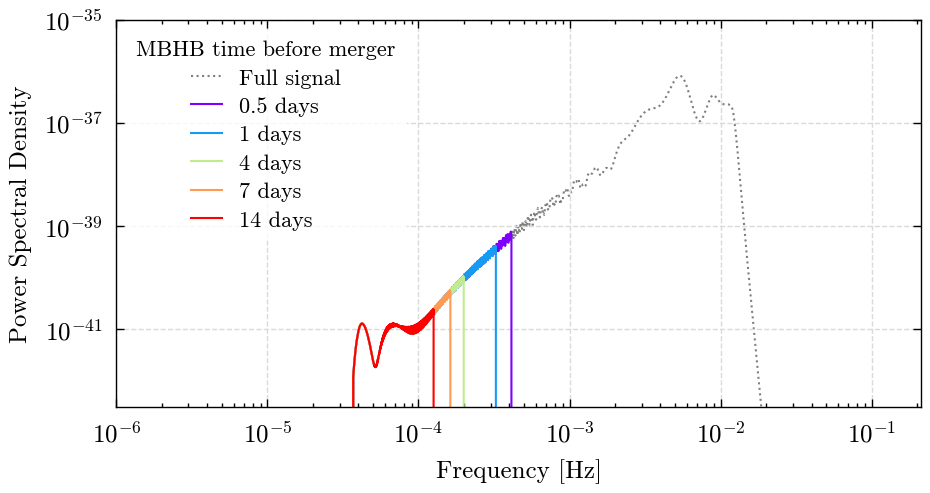

In [7]:
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    freqs,
    full_char ** 2 / freqs,
    c='k',
    label='Full signal',
    linestyle=':',
    zorder=-100,
    alpha=0.5
)
for days in cutoff_days:

    ax.loglog(
        freqs,
        char[days] ** 2 / freqs,
        color=time_before_colors[days],
        label=f'{days} days',
    )

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency [Hz]")
ax.grid()
ax.legend(title='MBHB time before merger', loc='upper left')
ax.set_xlim(left=1e-6)
ax.set_ylim([3e-43, 1e-35])
fig.show()

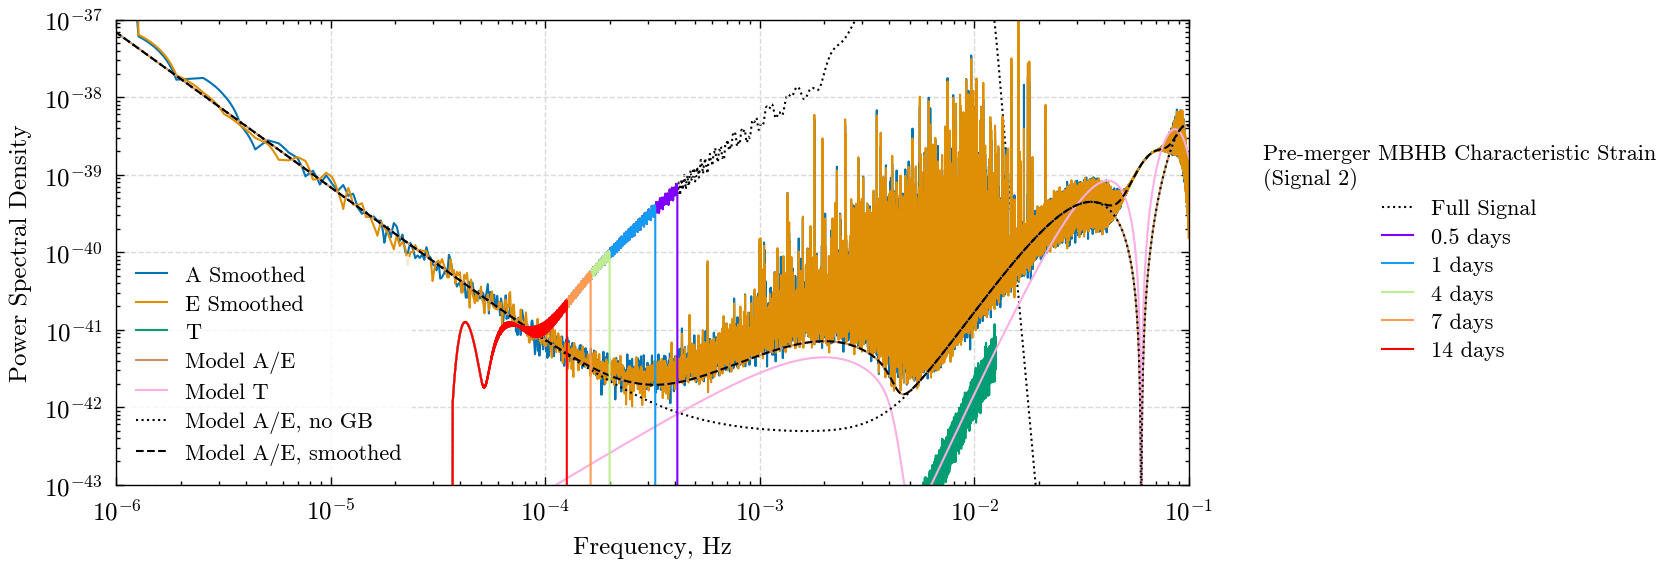

In [8]:
width = plt.rcParams["figure.figsize"][0] * 2
height = plt.rcParams["figure.figsize"][1] * 1.5
fig, ax = plt.subplots(1, figsize=(width, height))
ax.loglog(
    A_smoothed.sample_frequencies,
    A_smoothed,
    c=cycle[0],
    label='A Smoothed'
    )
ax.loglog(
    E_smoothed.sample_frequencies,
    E_smoothed,
    c=cycle[1],
    label='E Smoothed'
)
ax.loglog(
    T_estimate.sample_frequencies,
    T_estimate,
    c=cycle[2],
    label='T'
)
ax.loglog(
    AE_model.sample_frequencies,
    AE_model,
    c=cycle[5],
    label='Model A/E'
)
ax.loglog(
    T_model.sample_frequencies,
    T_model,
    c=cycle[6],
    label='Model T'
)
ax.loglog(
    sangria_model_freqs,
    ae_nogb,
    c='k',
    linestyle=':',
    label='Model A/E, no GB'
)
ax.loglog(
    AE_model_smoothed.sample_frequencies,
    AE_model_smoothed,
    c='k',
    linestyle='--',
    label='Model A/E, smoothed'
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='lower left')
line2 = []
labels2 = []

full_h_c= load_frequencyseries(
    f'characteristic_strain/characteristic_strain_{example_signal_number}_full.txt'
)
ax.loglog(
    freqs,
    full_char ** 2 / freqs,
    c='k',
    linestyle=':',
    zorder=-100,
)

line2.append(
    ax.loglog(
        [],
        [],
        color='k',
        linestyle=':',
    )[0]
)
labels2.append('Full Signal')
for days in cutoff_days:

    ax.loglog(
        freqs,
        char[days] ** 2 / freqs,
        color=time_before_colors[days],
        label=f'{days} days'
    )
    line2.append(
        ax.loglog(
            [],
            [],
            color=time_before_colors[days],
        )[0]
    )
    labels2.append(f'{days} days' if days > 0 else 'Full Signal')

leg2 = ax.legend(
    line2,
    labels2,
    loc="center left",
    title=f"Pre-merger MBHB Characteristic Strain\n(Signal {example_signal_number})",
    bbox_to_anchor=(1.05,0.5),
)
ax.add_artist(leg1)
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

fig.savefig(f'{paper_plot_dir}/figure_X_psds_with_sources.png')